In [5]:
import pandas as pd
import os
import shutil
import subprocess
from tqdm import tqdm
import json
from ast import literal_eval
import re
import requests
from Bio import pairwise2
import pickle
import sys
sys.path.append('../')
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

from common import *

# input and output

In [6]:
data = {
    "[Enterococcaceae] Enterococcus thailandicus DA450":{'levodopa-before':30,'levodopa-after':30},
    "[Enterococcaceae] Enterococcus hirae DA802":{'levodopa-before':30,'levodopa-after':0},
    "[Enterococcaceae] Enterococcus lactis DA296":{'levodopa-before':30,'levodopa-after':2.22},
    "[Enterococcaceae] Enterococcus lactis DA470":{'levodopa-before':30,'levodopa-after':18.63},
    "[Enterococcaceae] Enterococcus faecalis DA462":{'levodopa-before':30,'levodopa-after':0},
    "[Clostridiaceae] Paraclostridium bifermentans DA1293":{'levodopa-before':30,'levodopa-after':20.62},
    "[Clostridiaceae] Clostridium baratii DA411":{'levodopa-before':30,'levodopa-after':0},
    "Control":{'levodopa-before':30,'levodopa-after':30},
}

In [7]:
cmap = ['#A2C4E0','#B56576']

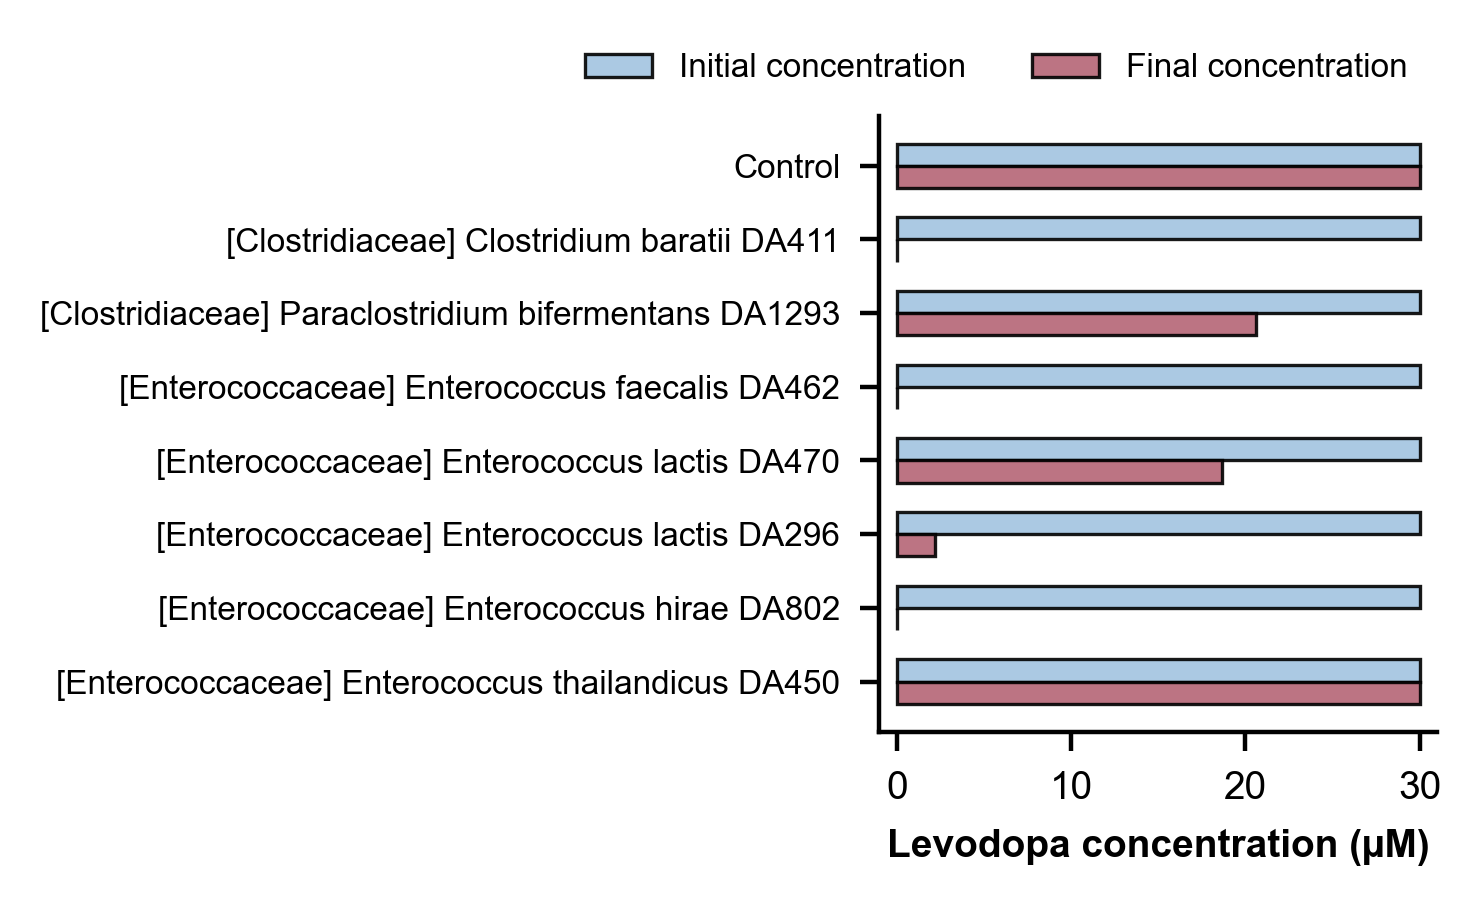

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# ===== 数据准备 =====
labels = list(data.keys())
levodopa = [data[k]['levodopa-before'] for k in labels]
dopamine = [data[k]['levodopa-after'] for k in labels]

x = np.arange(len(labels))
height = 0.3  # 横向柱子的宽度（即高度）

# ===== 画布 =====
plt.figure(figsize=(1.8, 2), dpi=400)
plt.rcParams.update({'font.size': 7, 'font.family': 'Arial', 'pdf.fonttype': 42})

ax = plt.gca()
ax.spines['top'].set_linewidth(0)
ax.spines['right'].set_linewidth(0)

# ===== 横向柱状图 (barh) =====
# 注意：barh 的第一个参数是 y 轴位置，第二个是柱子的长度
plt.barh(x + height/2, levodopa, height, label='Initial concentration', color='#A2C4E0', edgecolor='black', linewidth=0.6, alpha=0.9)
plt.barh(x - height/2, dopamine, height, label='Final concentration', color='#B56576', edgecolor='black', linewidth=0.6, alpha=0.9)

# ===== 坐标轴 =====
plt.yticks(x, labels, fontsize=6)  # 横向图中，标签在 y 轴
plt.xlabel('Levodopa concentration (µM)', fontsize=7, fontweight='bold') # 标签变成了 x 轴
plt.xlim(-1, 31) # 限制 x 轴范围

plt.legend(
    frameon=False,
    fontsize=6,
    ncol=2,
    loc='upper right',         # 调整了图例位置，避免挡住左侧的标签
    bbox_to_anchor=(1.0, 1.15) # 根据需要微调了位置
)

plt.savefig('../../Figure/Figure-3d.pdf', dpi=400, bbox_inches='tight')

plt.show()